In [3]:
import pandas as pd
url = 'https://raw.githubusercontent.com/kanetkar/LULML/refs/heads/main/ch07/loan.csv'
df = pd.read_csv(url)
print(df.head( ))
df.info( )


    Age  Monthly_Expenses   Income      Loan_Type  Default
0  39.0               NaN  72517.0      Home Loan        0
1  33.0            3465.0  20000.0      Auto Loan        0
2   NaN            3019.0  47109.0      Auto Loan        0
3  50.0            3005.0  20000.0  Personal Loan        0
4  32.0            3133.0  69590.0      Auto Loan        0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               405 non-null    float64
 1   Monthly_Expenses  475 non-null    float64
 2   Income            480 non-null    float64
 3   Loan_Type         488 non-null    object 
 4   Default           500 non-null    int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 19.7+ KB


In [4]:
missing_percentages = (df.isnull().sum() / len(df)) * 100
print(missing_percentages)


Age                 19.0
Monthly_Expenses     5.0
Income               4.0
Loan_Type            2.4
Default              0.0
dtype: float64


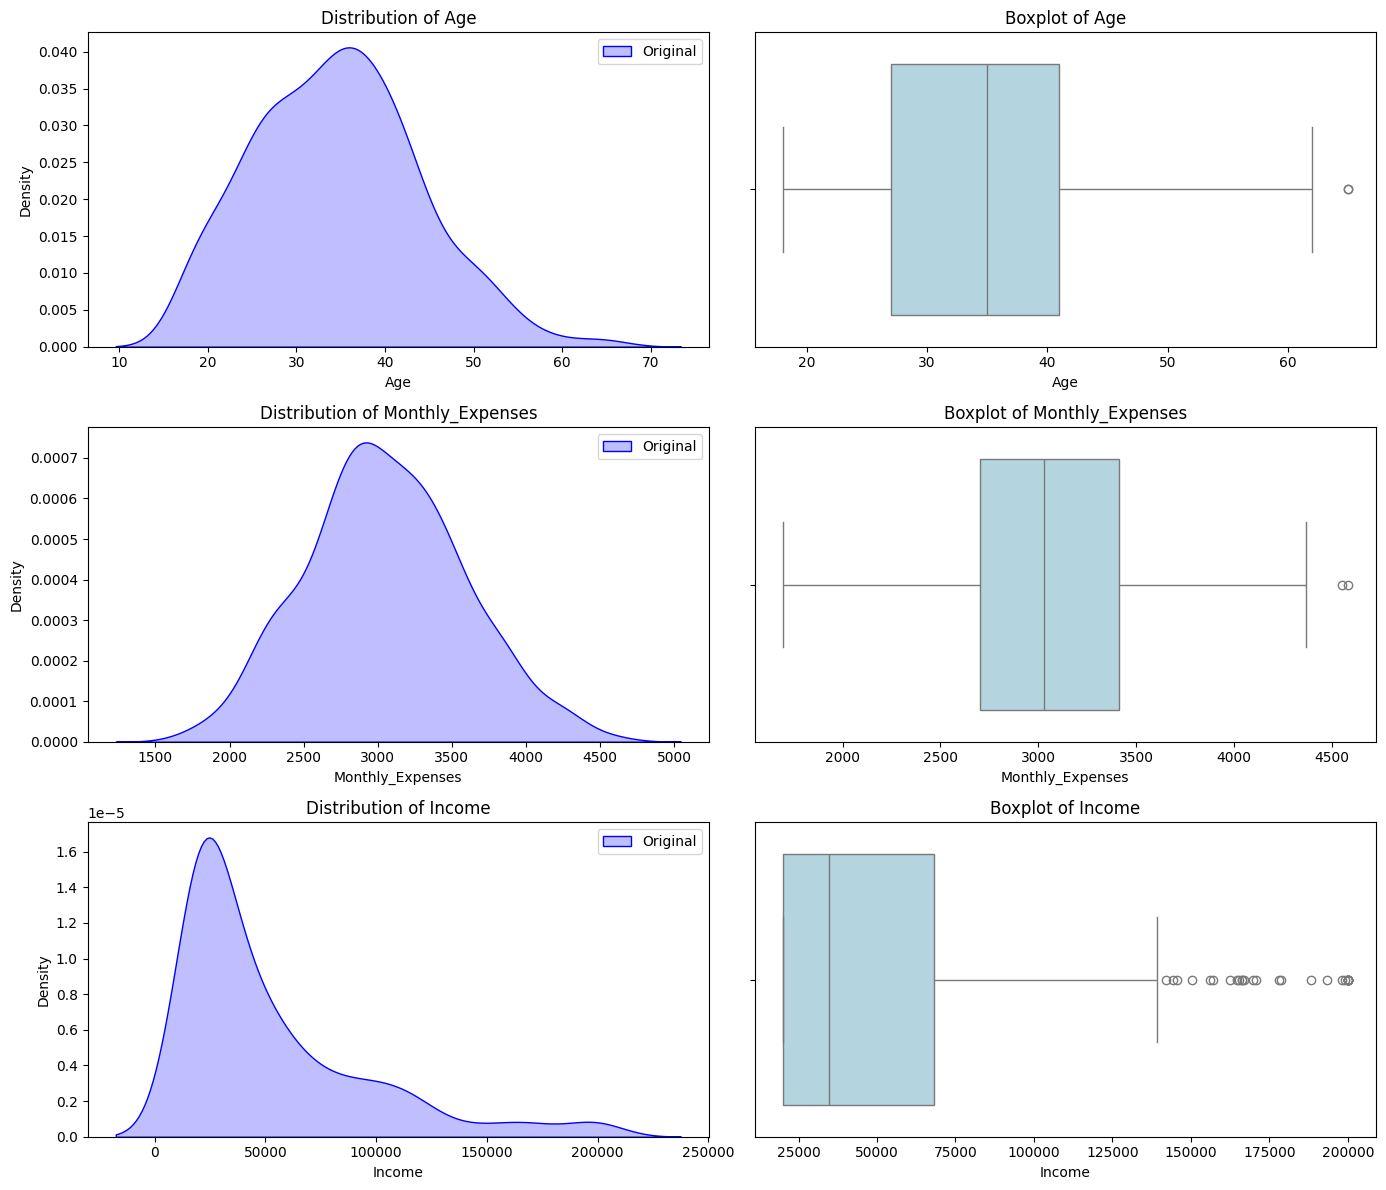

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_features = ['Age', 'Monthly_Expenses', 'Income']
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
for i, feature in enumerate(numerical_features):
    sns.kdeplot(data=df, x=feature, fill=True, label='Original',
                          color='blue', ax=axes[i, 0])
    axes[i, 0].set_title(f'Distribution of {feature}')
    axes[i, 0].legend()
    sns.boxplot(data=df, x=feature, color='lightblue', ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot of {feature}')

plt.tight_layout( )
plt.show( )


/tmp/ipykernel_3895/3035556670.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = 'Loan_Type', palette = 'pastel')


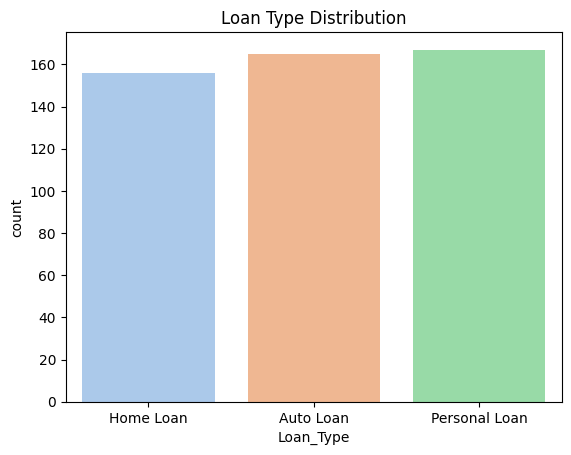

In [9]:
sns.countplot(data = df, x = 'Loan_Type', palette = 'pastel')
plt.title('Loan Type Distribution')
plt.show( )


In [10]:
from sklearn.impute import SimpleImputer
numerical_imputer_mean = SimpleImputer(strategy = 'mean')
numerical_imputer_median = SimpleImputer(strategy = 'median')
categorical_imputer = SimpleImputer(strategy = 'most_frequent')

df['Age_imputed'] = numerical_imputer_mean.fit_transform(df[['Age']])
df['Monthly_Expenses_imputed'] = numerical_imputer_mean.fit_transform(df[['Monthly_Expenses']])
df['Income_imputed'] = numerical_imputer_median.fit_transform(df[['Income']])
df['Loan_Type_imputed'] = categorical_imputer.fit_transform(df[['Loan_Type']]).ravel( )
print(df)


      Age  Monthly_Expenses    Income      Loan_Type  Default  Age_imputed  \
0    39.0               NaN   72517.0      Home Loan        0    39.000000   
1    33.0            3465.0   20000.0      Auto Loan        0    33.000000   
2     NaN            3019.0   47109.0      Auto Loan        0    34.548148   
3    50.0            3005.0   20000.0  Personal Loan        0    50.000000   
4    32.0            3133.0   69590.0      Auto Loan        0    32.000000   
..    ...               ...       ...            ...      ...          ...   
495  40.0            2801.0  198132.0      Auto Loan        0    40.000000   
496  24.0            3212.0   33025.0      Home Loan        1    24.000000   
497   NaN            3167.0   99588.0      Auto Loan        0    34.548148   
498  26.0            3077.0   44425.0  Personal Loan        0    26.000000   
499  21.0            4232.0   23526.0  Personal Loan        0    21.000000   

     Monthly_Expenses_imputed  Income_imputed Loan_Type_imputed

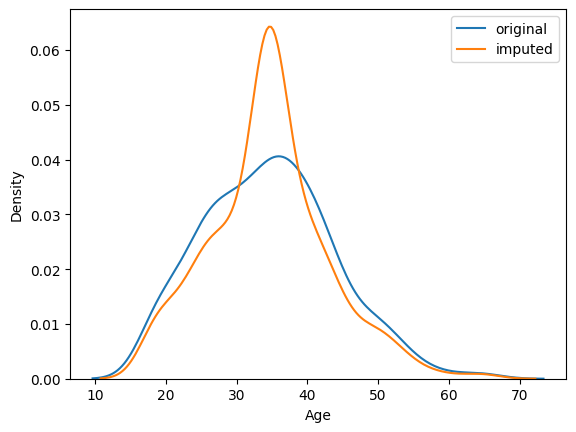

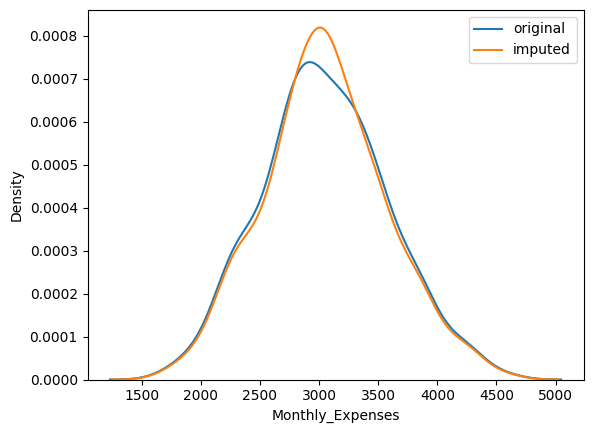

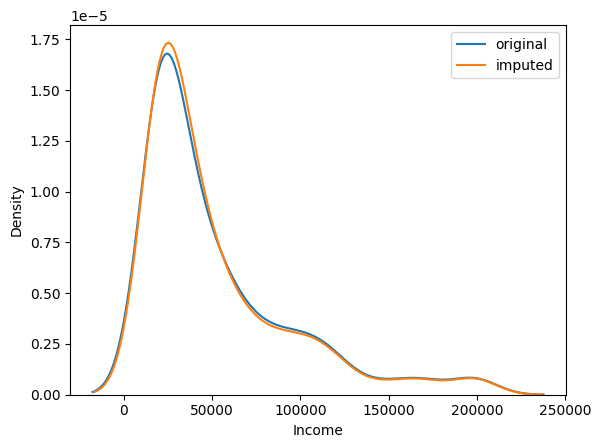

In [14]:
from sklearn.impute import SimpleImputer

numerical_imputer_mean = SimpleImputer(strategy = 'mean')
numerical_imputer_median = SimpleImputer(strategy = 'median')
categorical_imputer = SimpleImputer(strategy = 'most_frequent')

df['Age_imputed'] = numerical_imputer_mean.fit_transform(df[['Age']])
df['Monthly_Expenses_imputed'] = numerical_imputer_mean.fit_transform(df[['Monthly_Expenses']])
df['Income_imputed'] = numerical_imputer_median.fit_transform(df[['Income']])
df['Loan_Type_imputed'] = categorical_imputer.fit_transform(df[['Loan_Type']]).ravel( )

sns.kdeplot(df['Age'], label = 'original')
sns.kdeplot(df['Age_imputed'], label = 'imputed')
plt.legend( )
plt.show( )

sns.kdeplot(df['Monthly_Expenses'], label = 'original')
sns.kdeplot(df['Monthly_Expenses_imputed'], label = 'imputed')
plt.legend( )
plt.show( )

sns.kdeplot(df['Income'], label = 'original')
sns.kdeplot(df['Income_imputed'], label = 'imputed')
plt.legend( )
plt.show( )



In [16]:
categorical_imputer = SimpleImputer(strategy = 'most_frequent')
df['Loan_Type_imputed'] = categorical_imputer.fit_transform(df[['Loan_Type']]).ravel( )
df['Loan_Type'].value_counts(normalize = True)
df['Loan_Type_imputed'].value_counts(normalize = True)

loan_type_counts = df['Loan_Type'].value_counts(normalize = True)
loan_type_imputed_counts = df['Loan_Type_imputed'].value_counts(normalize = True)

# Combine into a single DataFrame
comparison_df = pd.DataFrame({
    'Original Loan_Type': loan_type_counts,
    'Imputed Loan_Type': loan_type_imputed_counts})
print(comparison_df)



               Original Loan_Type  Imputed Loan_Type
Personal Loan            0.342213              0.358
Auto Loan                0.338115              0.330
Home Loan                0.319672              0.312
